# **CMSC 320 - FINAL PROJECT**

In [ ]:
#imports
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
from scipy import stats

**PART 1 - DATA PROCESSING**

We are using Earthquake data from the USGS earthquake data website.  This data is from June 1st, 2005 to September 27th, 2012. It includes not only earthquake data but data involving Volcano Eruption and Landsides all of which has been reviewd in the context of Earthquakes.

In [3]:
earthquakes_df = pd.read_csv("Earthquakes.csv")
earthquakes_df

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2005-06-01T12:24:21.490Z,18.4620,-68.7530,148.1,4.2,mb,47.0,47.7,NaN,NaN,...,2014-11-07T01:26:03.100Z,"9 km WNW of San Rafael del Yuma, Dominican Rep...",earthquake,NaN,NaN,NaN,11.0,reviewed,rspr,us
1,2005-06-01T21:55:04.580Z,17.0910,-46.4740,10.0,5.0,mwc,241.0,44.7,NaN,0.72,...,2025-12-19T23:08:34.930Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,NaN,reviewed,us,hrv
2,2005-06-01T21:58:40.450Z,17.0670,-46.4480,10.0,4.8,mb,81.0,46.4,NaN,0.69,...,2014-11-07T01:26:04.203Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,30.0,reviewed,us,us
3,2005-06-02T04:50:07.800Z,19.4800,-103.5720,7.0,4.1,md,6.0,104.8,NaN,NaN,...,2014-11-07T01:26:04.430Z,"5 km NNW of Cofradía, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,unm,unm
4,2005-06-02T09:29:38.580Z,26.4510,-44.7070,10.0,4.7,mb,21.0,128.4,NaN,1.16,...,2014-11-07T01:26:04.558Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,12.0,reviewed,us,us
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2012-09-26T11:37:27.550Z,10.2180,-85.1100,57.1,4.2,mb,31.0,196.4,NaN,0.86,...,2014-11-07T01:48:55.204Z,"17 km WSW of Juntas, Costa Rica",earthquake,NaN,5.3,NaN,13.0,reviewed,us,us
15996,2012-09-26T18:15:22.200Z,14.8520,-61.2440,169.6,4.3,md,32.0,136.9,NaN,NaN,...,2014-11-07T01:48:55.280Z,"13 km W of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,trn,trn
15997,2012-09-26T22:23:23.940Z,26.8630,-44.2400,10.0,4.4,mb,40.0,88.6,NaN,1.04,...,2014-11-07T01:48:55.300Z,northern Mid-Atlantic Ridge,earthquake,NaN,NaN,NaN,10.0,reviewed,us,us
15998,2012-09-27T03:03:41.090Z,9.8210,-85.5690,36.7,4.4,mb,60.0,139.7,NaN,1.36,...,2014-11-07T01:48:55.505Z,"8 km SW of Sámara, Costa Rica",earthquake,NaN,9.5,NaN,32.0,reviewed,us,us


Information about the dataset before any modifications take place

In [4]:
print(f"df.shape: {earthquakes_df.shape}")
earthquakes_df.shape
print("df.describe(): ")
display(earthquakes_df.describe())
print("df.info(): ")
earthquakes_df.info()

df.shape: (16000, 22)
df.describe(): 


,latitude,longitude,depth,mag,nst,gap,dmin,rms,horizontalError,depthError,magError,magNst
count,16000.000000,16000.000000,16000.000000,16000.00000,14720.000000,14717.000000,1490.000000,7664.000000,1513.000000,4770.000000,1176.000000,6173.000000
mean,27.611573,-104.703152,38.187911,4.10787,47.583628,168.173160,0.278961,0.850562,1.483323,14.140468,0.191622,51.673092
std,16.763399,31.873068,43.143381,0.49540,77.578092,79.883874,0.357982,0.889954,5.029209,155.091728,0.157575,84.415456
min,7.959000,-171.562000,-2.285000,3.50000,0.000000,11.900000,0.001802,0.009800,0.080000,0.000000,0.000000,0.000000
25%,15.886000,-120.798542,10.000000,3.70000,8.000000,107.000000,0.054320,0.570000,0.300000,0.500000,0.134000,5.000000
50%,18.629000,-98.362000,19.000000,4.00000,18.000000,170.200000,0.166600,0.920000,0.580000,4.025000,0.163000,15.000000
75%,40.308958,-87.848000,51.700000,4.40000,49.000000,219.800000,0.392775,1.150000,1.630000,12.000000,0.200000,50.000000
max,72.852000,-36.609000,294.900000,7.60000,857.000000,358.300000,5.654000,69.320000,99.000000,9117.600000,1.680000,438.000000


df.info(): 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             16000 non-null  object 
 1   latitude         16000 non-null  float64
 2   longitude        16000 non-null  float64
 3   depth            16000 non-null  float64
 4   mag              16000 non-null  float64
 5   magType          16000 non-null  object 
 6   nst              14720 non-null  float64
 7   gap              14717 non-null  float64
 8   dmin             1490 non-null   float64
 9   rms              7664 non-null   float64
 10  net              16000 non-null  object 
 11  id               16000 non-null  object 
 12  updated          16000 non-null  object 
 13  place            16000 non-null  object 
 14  type             16000 non-null  object 
 15  horizontalError  1513 non-null   float64
 16  depthError       4770 non-null   float64
 17  

Parse data: Sort by magnitude

In [5]:
#sort by mag highest to smallest
earthquakes_df = earthquakes_df.sort_values(by=['mag'], ascending=False).reset_index(drop='True')

#this line below is to check if there was mag error, there is, maybe we could use it
#earthquakes_df = earthquakes_df.dropna(subset=['magError'])

#date only column, in datetime (remove .dt.date to get full date and time in datetime format)
date = pd.to_datetime(earthquakes_df['time']).dt.date
earthquakes_df.insert(0, 'date', date)
display(earthquakes_df)

,date,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2012-09-05,2012-09-05T14:42:07.800Z,10.085,-85.315,35.0,7.6,mww,703.0,34.3,NaN,...,2025-01-03T07:43:01.170Z,"11 km ENE of Hojancha, Costa Rica",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
1,2007-11-29,2007-11-29T19:00:20.420Z,14.944,-61.274,156.0,7.4,mwb,663.0,13.4,NaN,...,2022-07-13T02:37:48.411Z,"18 km WNW of Basse-Pointe, Martinique",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
2,2012-03-20,2012-03-20T18:02:47.440Z,16.493,-98.231,20.0,7.4,mww,672.0,37.9,NaN,...,2022-05-03T15:34:09.063Z,"6 km E of Santiago Llano Grande, Mexico",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
3,2012-08-27,2012-08-27T04:37:19.430Z,12.139,-88.590,28.0,7.3,mww,417.0,37.0,NaN,...,2022-05-03T15:48:15.643Z,"126 km S of Puerto El Triunfo, El Salvador",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
4,2009-05-28,2009-05-28T08:24:46.560Z,16.731,-86.217,19.0,7.3,mwc,464.0,27.2,NaN,...,2025-07-03T19:11:11.454Z,"46 km NW of Guanaja, Honduras",earthquake,NaN,NaN,NaN,NaN,reviewed,us,gcmt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15995,2007-10-01,2007-10-01T10:24:44.890Z,43.374,-126.586,10.0,3.5,ml,36.0,207.1,NaN,...,2014-11-07T01:33:46.672Z,"179 km W of Bandon, Oregon",earthquake,NaN,NaN,NaN,NaN,reviewed,us,us
15996,2006-03-07,2006-03-07T07:39:48.790Z,19.118,-63.884,5.0,3.5,md,8.0,317.1,NaN,...,2014-11-07T01:28:29.244Z,"129 km NE of Cruz Bay, U.S. Virgin Islands",earthquake,NaN,NaN,NaN,NaN,reviewed,rspr,rspr
15997,2007-09-30,2007-09-30T20:14:31.240Z,53.443,-161.462,10.0,3.5,ml,9.0,183.4,NaN,...,2019-02-13T07:25:01.376Z,"188 km SSE of King Cove, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,us,pmr
15998,2009-05-28,2009-05-28T12:39:49.210Z,54.014,-164.487,55.8,3.5,ml,26.0,196.1,NaN,...,2019-02-13T11:58:01.342Z,"85 km E of Akutan, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,aeic,aeic


Graph plotted below for Method 1: Based on magnitude and depth


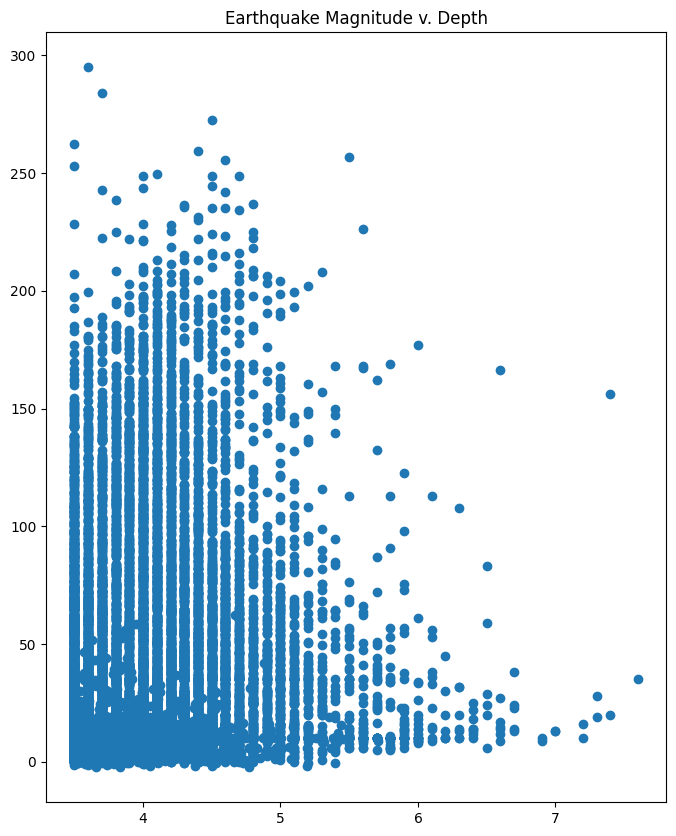

In [6]:
#write code here to plot graph this is mag v depth

#but this looks like a lot, maybes we just plot frequency of mags,
#or we narrow the range (groupby locationSource) for 'us' in locationSource before we plot
plt.figure(figsize=(8, 10))
plt.scatter(earthquakes_df['mag'], earthquakes_df['depth'])
plt.title("Earthquake Magnitude v. Depth")
plt.show()

Graph plotted below for Method 2:

To better visualize the correlation between how often the earthquakes happen and which regions get the most number of earthquakes, we will use a bar chart and a pie chart. First we want to see how frequent are the earthquakes in the regions in our database. We noticed that most of the regions had only 1 earthquake, with the graph having a right skew that is almost imposible to be seen on the graph. From the first graph we understood that most of the regions in our data base had less than 20 earthquakes. 

We wanted to take a closer look at the regions that have more than 20 earthquakes. We wanted to see exactly which regions are prone to having more earthquakes and their exact number of earthquakes. We notice that there are 2 regions with an astonishing amount of earthquakes, more than 100. This made us wonder what is the distribution of the frequency of earthquakes. Among out dataset, what is the percentage of regions that suffered 1 earthquake, between 2 and 20, and finally, more than 21. For this question we used the pie chart which perfectly shows that almost 88% of the regions have suffered only 1 earthquake, while 0.055% have suffered more than 21 earthquakes.

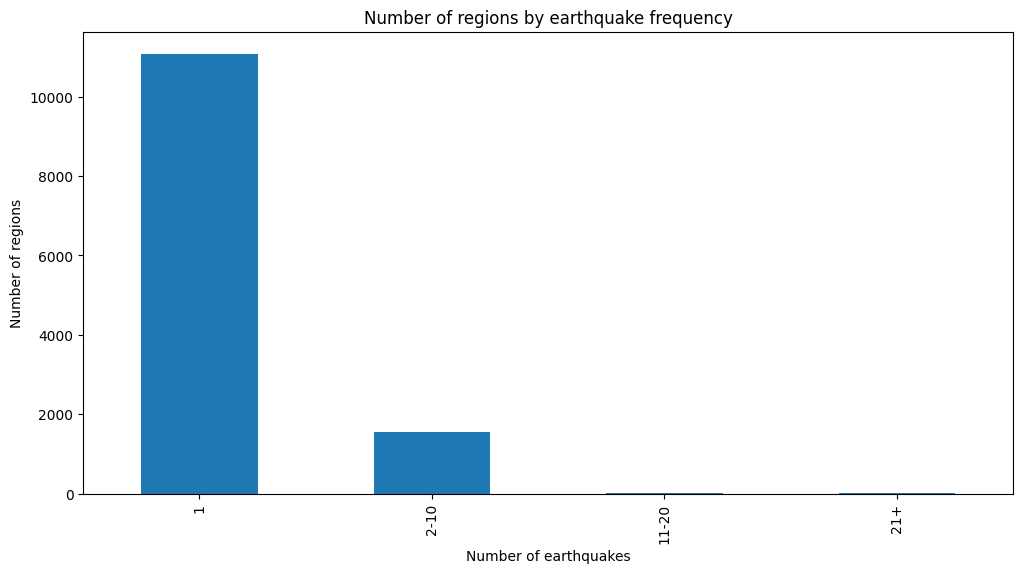

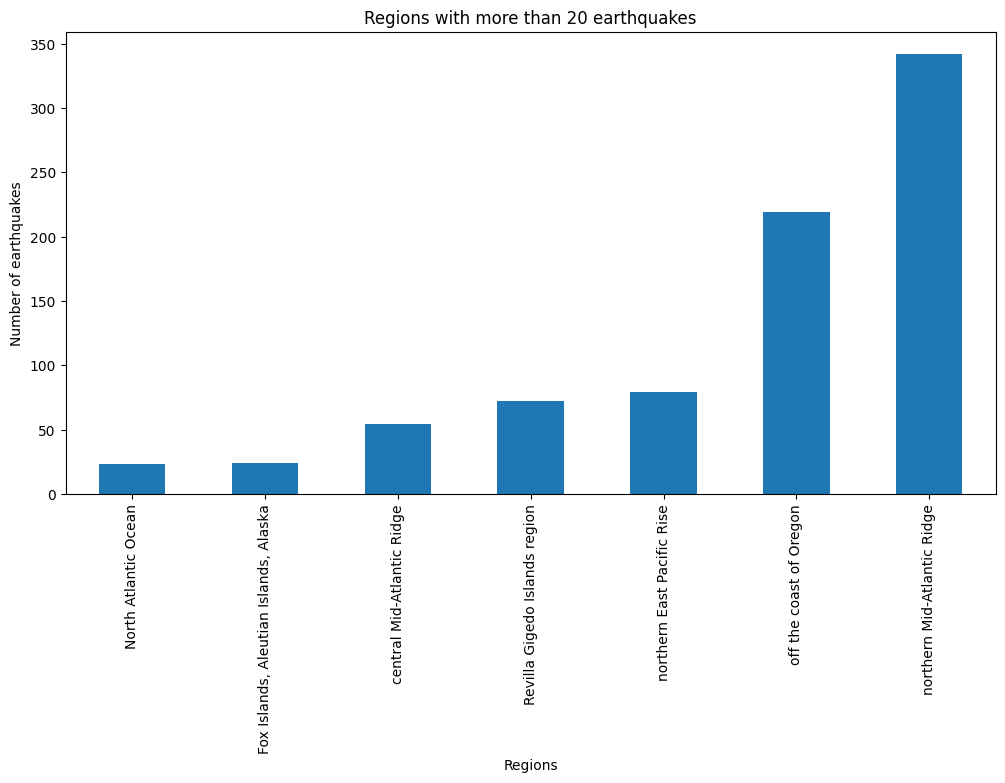

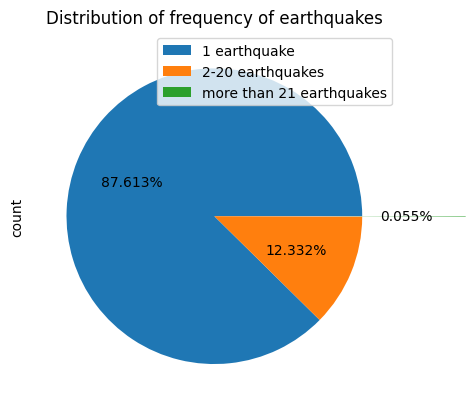

In [7]:
place_types = earthquakes_df['place'].value_counts()


bins = [0,1, 10, 20, float('inf')]
labels = ['1','2-10', '11-20', '21+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()

binned_occurences.plot(kind='bar', figsize=(12, 6))
plt.title('Number of regions by earthquake frequency')
plt.xlabel('Number of earthquakes')
plt.ylabel('Number of regions')

plt.show()

place_types_more_than_50_occurences = place_types[place_types > 20]

place_types_more_than_50_occurences.sort_values().plot(kind='bar', figsize=(12,6))

plt.title("Regions with more than 20 earthquakes")
plt.ylabel('Number of earthquakes')
plt.xlabel('Regions')
plt.show()


bins = [0,1, 20, float('inf')]
labels = ['1','2-20', '21+']

binned = pd.cut(place_types, bins = bins, labels=labels)
binned_occurences = binned.value_counts().sort_index()


legend=['1 earthquake', '2-20 earthquakes', 'more than 21 earthquakes']
myexplode=[0, 0, 0.7]
binned_occurences.plot(kind='pie', labels=None, autopct='%1.3f%%', explode=myexplode)
plt.title('Distribution of frequency of earthquakes')
plt.legend(legend)
plt.show()



Graph plotted below for Method 3 (Hypothesis): The average magnitude is the same between regions with higher frequency earthquakes and regions with lower frequency earthquakes.


High-frequency places mean magnitude: 4.437685714285714
Low-frequency places mean magnitude: 4.026595744680851
T-statistic: 9.451322585676547
P-value: 1.6160628113315133e-20


/var/folders/xd/jxx64k_x2bxb4pnfrhcxwk3h0000gn/T/ipykernel_93430/2377187226.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["High Freq", "Low Freq"])


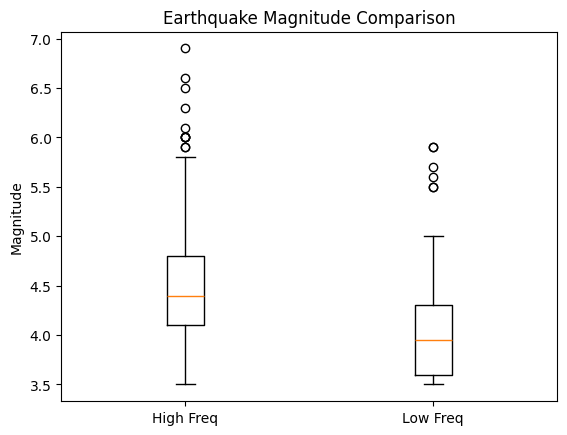

In [ ]:
#method 3
place_types = earthquakes_df['place'].value_counts().head(50)

high_freq_places = place_types[place_types >= place_types.median()].index
low_freq_places = place_types[place_types < place_types.median()].index


high_mag = earthquakes_df[earthquakes_df['place'].isin(high_freq_places)]['mag'].dropna()
low_mag = earthquakes_df[earthquakes_df['place'].isin(low_freq_places)]['mag'].dropna()


print("High-frequency places mean magnitude:", high_mag.mean())
print("Low-frequency places mean magnitude:", low_mag.mean())


results = stats.ttest_ind(high_mag, low_mag)


print(f"T-statistic: {results.statistic}")
print(f"P-value: {results.pvalue}")


data = [high_mag, low_mag]


plt.boxplot(data, labels=["High Freq", "Low Freq"])
plt.title("Earthquake Magnitude Comparison")
plt.ylabel("Magnitude")
plt.show()
